# Configuration settings

In [25]:
from pathlib import Path

# -------- Save-or-load wrapper --------
regenerate = True
# regenerate = False

# Need to retrain the tensors using the seed 2 stage 1 trained weights for the following datasets:
# bw10mbit_delay20_jitter5_loss0: seed1 [ ], seed2 [ ]
# bw30mbit_delay20_jitter5_loss0: seed1 [ ], seed2 [ ]
# bw50mbit_delay20_jitter5_loss0: seed1 [ ], seed2 [ ]
# bw100mbit_delay20_jitter5_loss0: seed1 [ ], seed2 [ ]

######## The dataset to be processed with an existing learned packet grouping model
######## Typically this will be the seed1 version of a dataset, after training the packet grouper (stage 1) on the seed2 version
TO_PROCESS_seed_identifier = "seed1"
TO_PROCESS_carla_run_identifier = "separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy"
# network_configuration = "bw10mbit_delay0_jitter0_loss0"
TO_PROCESS_network_configuration = "bw100mbit_delay20_jitter5_loss0"

######## The dataset whose trained packet grouping model is used to predict the TO_PROCESS dataset
PRETRAINED_seed_identifier = "seed2"
PRETRAINED_carla_run_identifier = "separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy"
# network_configuration = "bw10mbit_delay0_jitter0_loss0"
PRETRAINED_network_configuration = "bw100mbit_delay20_jitter5_loss0"

print(f"clustering packets from dataset: {TO_PROCESS_seed_identifier}/{TO_PROCESS_network_configuration}/{TO_PROCESS_network_configuration}")
print(f"using grouping weights from dataset: {PRETRAINED_seed_identifier}/{PRETRAINED_network_configuration}/{PRETRAINED_network_configuration}")
device = "cuda:1"
DATA_ROOT = Path(f"/home/gaofeng/zanoria/grayassets_datasets/{TO_PROCESS_seed_identifier}/{TO_PROCESS_carla_run_identifier}/indexed_samples/packetsizes") / TO_PROCESS_network_configuration
MUST_CONTAIN = ["video_camera", "pkts"]

OUTPUT_TENSORS_ROOT = Path(f"/home/gaofeng/zanoria/grayassets_datasets/{TO_PROCESS_seed_identifier}/{TO_PROCESS_carla_run_identifier}/tensors/packetsizes/{TO_PROCESS_network_configuration}")
TO_PROCESS_TENSORS_ROOT = OUTPUT_TENSORS_ROOT / "packet_grouping_training_tensors"
TO_PROCESS_TENSORS_ROOT.mkdir(parents=True, exist_ok=True)

MODEL_PATH = Path(f"/home/gaofeng/zanoria/grayassets_datasets/{PRETRAINED_seed_identifier}/{PRETRAINED_carla_run_identifier}/tensors/packetsizes/{PRETRAINED_network_configuration}/packet_grouping_model_weights/best_packetsegformer.pkl")

clustering packets from dataset: seed1/bw100mbit_delay20_jitter5_loss0/bw100mbit_delay20_jitter5_loss0
using grouping weights from dataset: seed2/bw100mbit_delay20_jitter5_loss0/bw100mbit_delay20_jitter5_loss0


# Preprocessing

In [29]:
from typing import List, Tuple, Optional, Dict
import numpy as np
import pandas as pd
import torch
import json

from pathlib import Path
from typing import List, Optional, Union
import re

# Required columns now include rtp.marker
REQUIRED_COLS = ["frame.time_relative", "frame.len", "rtp.marker"]

def find_candidate_csvs(
    root: str | Path,
    pattern: str = "*.csv",
    must_contain: Optional[List[str]] = None,
    sample_dir_regex = r"^sample_(\d+)$",
    camera_file_regex = r"^video_camera(\d+)_.*_1x_pktlen\.csv$",
) -> List[Path]:
    # compile if needed
    sample_re = re.compile(sample_dir_regex) if isinstance(sample_dir_regex, str) else sample_dir_regex
    camera_re = re.compile(camera_file_regex) if isinstance(camera_file_regex, str) else camera_file_regex

    root = Path(root).expanduser().resolve()

    def _extract_sample_idx(p: Path) -> Optional[int]:
        # Walk up parents to find a folder matching sample_dir_regex
        for part in p.parents:
            m = sample_re.match(part.name)
            if m:
                try:
                    return int(m.group(1))
                except (IndexError, ValueError):
                    return None
        return None

    def _extract_camera_idx(fname: str) -> Optional[int]:
        m = camera_re.match(fname)
        if not m:
            return None
        try:
            return int(m.group(1))
        except (IndexError, ValueError):
            return None

    candidates = []
    for p in root.rglob(pattern):
        if not p.is_file():
            continue

        if must_contain and not any(tok in p.name for tok in must_contain):
            continue

        sidx = _extract_sample_idx(p)
        if sidx is None:
            continue

        cidx = _extract_camera_idx(p.name)
        if cidx is None:
            continue

        candidates.append((sidx, cidx, p))

    # Sort: sample-major (numeric), then camera index (numeric)
    candidates.sort(key=lambda t: (t[0], t[1]))

    return [p for _, _, p in candidates]

def file_has_required_cols(path: Path) -> bool:
    try:
        sample = pd.read_csv(path, nrows=20)
        return all(c in sample.columns for c in REQUIRED_COLS)
    except Exception:
        return False

def read_one_csv(path: Path) -> Tuple[np.ndarray, np.ndarray]:
    """
    Read one CSV and return:
      X_norm: [N, 2] float32 -> [frame.time_relative (absolute), frame.len]
      marker: [N]     bool    -> rtp.marker (True marks the *last* packet of a frame)
    Notes:
      - We will convert X_norm[:,0] (absolute times) into deltas later,
        and shift all targets by one to align with "time since previous packet".
    """
    df = pd.read_csv(
        path,
        usecols=REQUIRED_COLS,
        dtype={
            "frame.time_relative": "float64",
            "frame.len": "float64",
            "rtp.marker": "object",  # robust: handle 0/1, "True"/"False"
        },
    )

    # Normalize marker to boolean
    # Accepts: 1/0, "1"/"0", "true"/"false", True/False
    def _to_bool(v):
        if pd.isna(v):
            return False
        if isinstance(v, (int, np.integer, bool, np.bool_)):
            return bool(v)
        s = str(v).strip().lower()
        return s in ("1", "true", "t", "yes", "y")

    df["rtp.marker"] = df["rtp.marker"].map(_to_bool)

    df = df.dropna(subset=["frame.time_relative", "frame.len"])
    if df.empty:
        return np.zeros((0, 2), dtype=np.float32), np.zeros((0,), dtype=bool)

    # Sort by time (stable)
    df = df.sort_values("frame.time_relative", kind="mergesort")

    X_norm = df[["frame.time_relative", "frame.len"]].to_numpy(dtype=np.float32)  # [N,2]
    marker = df["rtp.marker"].to_numpy(dtype=bool)                                # [N]
    return X_norm, marker

def build_padded_packet_tensors(
    root: str | Path,
    pattern: str = "*.csv",
    must_contain: Optional[List[str]] = None,  # e.g., ["video_camera", "pkts"]
    device_preference: str = "cuda",
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, List[Path], np.ndarray, np.ndarray]:
    """
    Returns:
      X:                 [S, N_max, 2] float32 on device (Δtime_since_prev, frame.len), PAD = -1.0
      y:                 [S, N_max]    bool    on device (boundary=True/False),       PAD = False
      mask:              [S, N_max]    bool    on device (True = real, False = pad)
      frame_assignments: [S, N_max]    int64   on device (frame_id 0..F_i-1),         PAD = -1
      paths:             list[Path]
      lengths:           np.ndarray[S] original per-file *post-shift* lengths (N_i - 1)
      num_frames:        np.ndarray[S] total frames per file (sum of markers, with last forced)
    """
    # 1) Find viable CSVs
    candidates = find_candidate_csvs(root, pattern=pattern, must_contain=must_contain)
    viable = [p for p in candidates if file_has_required_cols(p)]
    if not viable:
        raise RuntimeError("No CSVs with required columns found under the root path.")
    print(f"Found {len(viable)} CSV(s) with required columns.")

    per_X: List[np.ndarray] = []
    per_frame_ids: List[np.ndarray] = []
    per_boundary: List[np.ndarray] = []
    lengths: List[int] = []
    num_frames_list: List[int] = []

    # 2) Process each CSV using rtp.marker
    for i, p in enumerate(viable, 1):
        try:
            X_norm, marker = read_one_csv(p)  # X_norm: [N,2], marker: [N] bool (end-of-frame)
            N = X_norm.shape[0]
            if N == 0:
                # empty
                per_X.append(np.zeros((0, 2), dtype=np.float32))
                per_frame_ids.append(np.zeros((0,), dtype=np.int64))
                per_boundary.append(np.zeros((0,), dtype=bool))
                lengths.append(0)
                num_frames_list.append(0)
                continue

            # Ensure the last packet ends a frame (if not already)
            if not marker[-1]:
                marker = marker.copy()
                marker[-1] = True

            # ---------------------------
            # Frame assignments from marker:
            #   - marker marks the LAST packet of a frame
            #   - the marker packet belongs to the PRECEDING frame
            #   - frame id increments *after* a marker
            # So frame_id[i] = cumsum(prev_marker up to i-1), starting at 0
            prev_marker = np.concatenate([[0], marker[:-1].astype(np.int64)], axis=0)  # [N]
            frame_ids = np.cumsum(prev_marker).astype(np.int64)  # 0..F-1
            F_i = int(marker.sum())  # total frames
            # ---------------------------

            # Boundaries (end-of-frame) are directly the marker flags
            bvec = marker.astype(bool)  # [N] True where frame ends

            # ---------------------------
            # Build Δtime feature and align targets:
            #   X = [Δtime, frame.len] for indices 1..N-1
            #   frame_assignments = frame_ids[1:]
            #   boundary y = bvec[1:]  (boundary at current index)
            # ---------------------------
            abs_t = X_norm[:, 0].astype(np.float32)  # absolute times
            pkt_sz = X_norm[:, 1].astype(np.float32)
            dt = abs_t[1:] - abs_t[:-1]             # [N-1]
            X_win = np.stack([dt, pkt_sz[1:]], axis=1).astype(np.float32)  # [N-1,2]

            fa_shift = frame_ids[1:].astype(np.int64)  # [N-1]
            b_shift  = bvec[1:].astype(bool)           # [N-1]

            per_X.append(X_win)
            per_frame_ids.append(fa_shift)
            per_boundary.append(b_shift)
            lengths.append(len(fa_shift))  # N-1
            num_frames_list.append(F_i)
        except Exception as e:
            print(f"  ! Skipping {p} due to error: {e}")

    if not per_X:
        raise RuntimeError("All candidate CSVs failed to load.")

    lengths = np.asarray(lengths, dtype=np.int64)
    num_frames = np.asarray(num_frames_list, dtype=np.int64)
    S = len(per_X)
    N_max = int(lengths.max() if lengths.size else 0)
    print(f"Sequences: {S} | Max length: {N_max}")

    # 3) Allocate padded arrays (CPU first)
    X_pad  = np.full((S, N_max, 2), fill_value=-1.0, dtype=np.float32)
    y_pad  = np.zeros((S, N_max), dtype=bool)           # boundary: pad=False
    fa_pad = np.full((S, N_max), fill_value=-1, dtype=np.int64)
    mask   = np.zeros((S, N_max), dtype=bool)

    # 4) Fill with per-file data
    for s, (Xi, fa_i, b_i) in enumerate(zip(per_X, per_frame_ids, per_boundary)):
        n = len(fa_i)
        if n == 0:
            continue
        X_pad[s, :n, :] = Xi
        fa_pad[s, :n]   = fa_i
        y_pad[s,  :n]   = b_i
        mask[s,   :n]   = True

    # 5) Move to target device
    device = (
        torch.device(device_preference) if device_preference == "cpu"
        else torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
    )
    X = torch.from_numpy(X_pad).to(device, dtype=torch.float32, non_blocking=True)
    y = torch.from_numpy(y_pad).to(device, dtype=torch.bool,     non_blocking=True)  # boundary bool (end-of-frame)
    mask_t = torch.from_numpy(mask).to(device, non_blocking=True)
    frame_assignments = torch.from_numpy(fa_pad).to(device, dtype=torch.int64, non_blocking=True)

    return X, y, mask_t, frame_assignments, viable, lengths, num_frames

# ---------- Helpers to save/load a prepared dataset (unchanged) ----------
def save_dataset(save_dir: Path, X: torch.Tensor, y: torch.Tensor, mask: torch.Tensor,
                 paths: list[Path], lengths: np.ndarray, num_frames: np.ndarray,
                 frame_assignments: torch.Tensor):
    save_dir.mkdir(parents=True, exist_ok=True)

    X_to_save  = X.detach()
    y_to_save  = y.detach().to(torch.bool)
    m_to_save  = mask.detach().to(torch.bool)
    fa_to_save = frame_assignments.detach().to(torch.int64)

    torch.save(X_to_save,  save_dir / "X.pt")
    torch.save(y_to_save,  save_dir / "y_boundary.pt")
    torch.save(m_to_save,  save_dir / "mask.pt")
    torch.save(fa_to_save, save_dir / "frame_assignments.pt")

    np.save(save_dir / "lengths.npy",    lengths.astype(np.int64))
    np.save(save_dir / "num_frames.npy", num_frames.astype(np.int64))

    with (save_dir / "paths.txt").open("w") as f:
        for p in paths:
            f.write(str(p) + "\n")

    print(f"[save_dataset] Saved to {save_dir.resolve()}")
    print(f"  X: {tuple(X_to_save.shape)} {X_to_save.dtype} on {X_to_save.device}")
    print(f"  y_boundary: {tuple(y_to_save.shape)} {y_to_save.dtype} on {y_to_save.device}")
    print(f"  frame_assignments: {tuple(fa_to_save.shape)} {fa_to_save.dtype} on {fa_to_save.device}")
    print(f"  mask: {tuple(m_to_save.shape)} {m_to_save.dtype} on {m_to_save.device}")
    print(f"  lengths: {lengths.shape}, num_frames: {num_frames.shape}")

def load_dataset(load_dir: Path, device: torch.device):
    X   = torch.load(load_dir / "X.pt",                 map_location=device)
    y   = torch.load(load_dir / "y_boundary.pt",        map_location=device).to(torch.bool)
    m   = torch.load(load_dir / "mask.pt",              map_location=device).to(torch.bool)
    fa  = torch.load(load_dir / "frame_assignments.pt", map_location=device).to(torch.int64)
    lengths    = np.load(load_dir / "lengths.npy")
    num_frames = np.load(load_dir / "num_frames.npy")

    paths_file = load_dir / "paths.txt"
    if paths_file.exists():
        with paths_file.open("r") as f:
            paths = [Path(line.strip()) for line in f if line.strip()]
    else:
        paths = []

    print(f"[load_dataset] Loaded from {load_dir.resolve()}")
    print(f"  X: {tuple(X.shape)} {X.dtype} on {X.device}")
    print(f"  y_boundary: {tuple(y.shape)} {y.dtype} on {y.device}")
    print(f"  frame_assignments: {tuple(fa.shape)} {fa.dtype} on {fa.device}")
    print(f"  mask shape: {tuple(m.shape)} {m.dtype} on {m.device}")
    print(f"  lengths shape: {lengths.shape}, num_frames shape: {num_frames.shape}")
    return X, y, m, fa, paths, lengths, num_frames


## Run the generation script and save the outputs

In [30]:
if regenerate:
    X, y, mask, frame_assignments, paths, lengths, num_frames = build_padded_packet_tensors(
        root=DATA_ROOT,
        pattern="*.csv",
        must_contain=MUST_CONTAIN,
        device_preference=device,
    )
    for p in paths:
        print(p)
    # y is now boundary; frame_assignments holds the original per-packet frame ids
    # save_dataset(TO_PROCESS_TENSORS_ROOT, X, y, mask, paths, lengths, num_frames, frame_assignments)
else:
    X, y, mask, frame_assignments, paths, lengths, num_frames = load_dataset(
        TO_PROCESS_TENSORS_ROOT, device=torch.device(device)
)

Found 4040 CSV(s) with required columns.
Sequences: 4040 | Max length: 12515
/home/gaofeng/zanoria/grayassets_datasets/seed1/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/indexed_samples/packetsizes/bw100mbit_delay20_jitter5_loss0/sample_0/video_camera1_pkts_1x_pktlen.csv
/home/gaofeng/zanoria/grayassets_datasets/seed1/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/indexed_samples/packetsizes/bw100mbit_delay20_jitter5_loss0/sample_0/video_camera2_pkts_1x_pktlen.csv
/home/gaofeng/zanoria/grayassets_datasets/seed1/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/indexed_samples/packetsizes/bw100mbit_delay20_jitter5_loss0/sample_0/video_camera3_pkts_1x_pktlen.csv
/home/gaofeng/zanoria/grayassets_datasets/seed1/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/indexed_samples/packetsizes/bw100mbit_delay20_jit

In [5]:
print(X[0,1:200,0])
print(y[0,1:200])
print(mask[0,1:200])
# print(X[1,1:200,0])
print(torch.stack([X[0,1:200,0], y[0,1:200]], dim=1))

tensor([8.8664e-04, 1.2400e-04, 1.2800e-04, 9.5693e-04, 1.2800e-04, 1.2699e-03,
        1.3100e-04, 4.3480e-05, 1.3300e-04, 1.1900e-04, 1.2200e-04, 1.2100e-04,
        1.1200e-04, 1.2000e-04, 1.3100e-04, 1.4200e-04, 1.0600e-04, 6.8327e-04,
        1.2300e-04, 1.1900e-04, 1.2100e-04, 1.2600e-04, 1.1600e-04, 1.2100e-04,
        1.2100e-04, 1.2200e-04, 1.2100e-04, 1.2000e-04, 1.2900e-04, 1.2300e-04,
        1.1300e-04, 1.3000e-04, 1.1800e-04, 1.4357e-04, 1.2100e-04, 1.2100e-04,
        1.2100e-04, 1.2200e-04, 1.2000e-04, 1.2000e-04, 1.2200e-04, 1.2100e-04,
        1.2100e-04, 1.2600e-04, 1.3300e-04, 1.0500e-04, 1.2500e-04, 1.2700e-04,
        1.3077e-04, 1.2100e-04, 1.2600e-04, 1.1700e-04, 1.1900e-04, 1.2800e-04,
        1.2000e-04, 1.1400e-04, 1.3400e-04, 1.1000e-04, 1.2600e-04, 1.1700e-04,
        1.2900e-04, 1.1700e-04, 1.1400e-04, 1.2800e-04, 1.2800e-04, 1.1000e-04,
        1.3800e-04, 1.1300e-04, 1.1300e-04, 1.2400e-04, 1.1500e-04, 1.2000e-04,
        1.2400e-04, 1.2000e-04, 1.3200e-

## Exclude the experiments missing the rtp data from those used in training

0


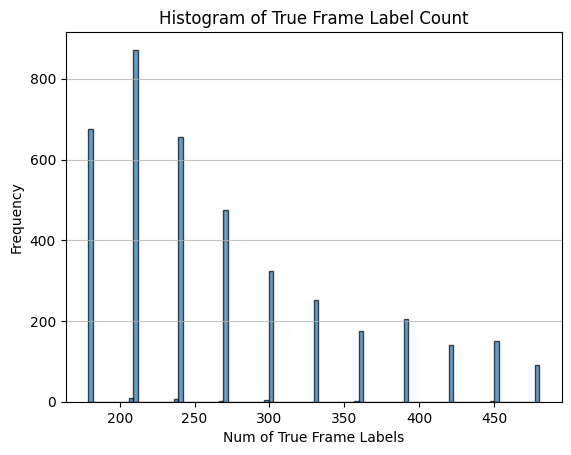

In [6]:
print(sum(num_frames < 100))
import matplotlib.pyplot as plt
import numpy as np


# 2. Create Histogram
plt.hist(num_frames, bins=100, edgecolor='black', alpha=0.7) # Adjust alpha for transparency

# 3. Add Labels and Title
plt.xlabel("Num of True Frame Labels")
plt.ylabel("Frequency")
plt.title("Histogram of True Frame Label Count")

# 4. Display Plot
plt.grid(axis='y', alpha=0.75) # Optional: Add a grid
plt.show()

In [7]:
print(num_frames)
bad_indices = np.where(num_frames < 150)[0]

print(f"{bad_indices=}")
print(f"{len(bad_indices)=}")

good_indices = np.delete(np.arange(len(num_frames)), bad_indices)
print(f"{len(num_frames)=}")
print(f"{good_indices=}")
print(f"{len(good_indices)=}")

[270 270 270 ... 480 480 480]
bad_indices=array([], dtype=int64)
len(bad_indices)=0
len(num_frames)=4040
good_indices=array([   0,    1,    2, ..., 4037, 4038, 4039])
len(good_indices)=4040


X: torch.Size([4040, 12515, 2]) torch.float32 cuda:1
y: torch.Size([4040, 12515]) torch.bool cuda:1
mask: torch.Size([4040, 12515]) torch.bool cuda:1
first 4 file lengths: [5252 6742 5972 6886]
first 4 file frame counts: [270 270 270 270]

sample0 (/home/gaofeng/zanoria/grayassets_datasets/seed1/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/indexed_samples/packetsizes/bw100mbit_delay20_jitter5_loss0/sample_0/video_camera1_pkts_1x_pktlen.csv) info:
sample_len=0.04368019104003906 (s)
num of frames predicted by windowing: 1.3104057312011719
actual num of frames: 10
[False False False ... False False False]
Sum of target tensor: 270
Actual number of frames: 270
Valid length of target tensor: 5252
Making sure the last boundary is True
tensor(True, device='cuda:1')
[5.83902001e-05 9.45033506e-04 1.06903352e-03 1.19703449e-03
 2.15396471e-03 2.28196383e-03 3.55187058e-03 3.68287042e-03
 3.72635014e-03 3.85935046e-03 3.97835113e-03 4.10035066e-03

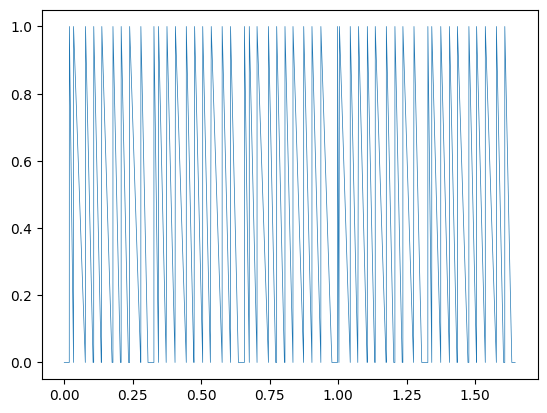

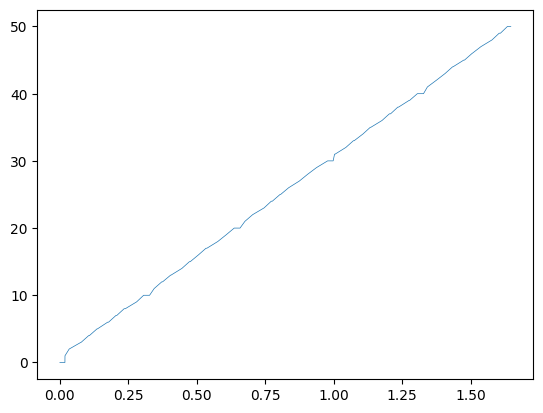

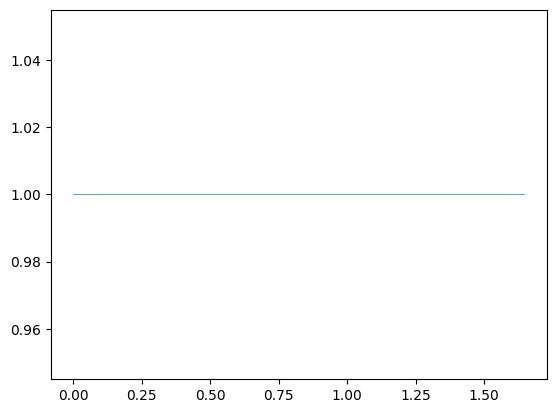

In [8]:
print("X:", X.shape, X.dtype, X.device)     # [S, N_max, 2]
print("y:", y.shape, y.dtype, y.device)     # [S, N_max]
print("mask:", mask.shape, mask.dtype, mask.device)
print("first 4 file lengths:", lengths[:4])
print("first 4 file frame counts:", num_frames[:4])
# print("first path:", paths[0] if len(paths) else None)

print(f"\nsample0 ({paths[0]}) info:")
sample_len = X[0,:,0].max().item()
print(f"{sample_len=} (s)")
print(f"num of frames predicted by windowing: {sample_len*30}")
print(f"actual num of frames: {y[0,:num_frames[0]].sum()}")


import matplotlib.pyplot as plt
xmin = 0
xmax = 1000
# xrange = range(len(y[0,xmin:xmax]))
xrange = np.cumsum(X[0,xmin:xmax,0].cpu().numpy())
plt.figure()
plt.plot(xrange,y[0,xmin:xmax].cpu().numpy(), linewidth=0.5)
plt.figure()
plt.plot(xrange,frame_assignments[0,xmin:xmax].cpu().numpy(), linewidth=0.5)
plt.figure()
plt.plot(xrange,mask[0,xmin:xmax].cpu().numpy(), linewidth=0.5)
print(y[0,:].cpu().numpy())
print(f"Sum of target tensor: {y[0,:].sum()}")
print(f"Actual number of frames: {num_frames[0]}")
print(f"Valid length of target tensor: {lengths[0]}")
print("Making sure the last boundary is True")
print(y[0,lengths[0]-1])

print(xrange)

In [9]:
import pandas as pd
# Extract unique values and counts
unique_vals, counts = frame_assignments[0, :].unique(return_counts=True)
# Move to CPU if on GPU
unique_vals = unique_vals.cpu().numpy()
counts = counts.cpu().numpy()
# Sort by label for readability
order = np.argsort(unique_vals)
unique_vals, counts = unique_vals[order], counts[order]
# Pretty print as a DataFrame
df = pd.DataFrame({
    "frame_id": unique_vals,
    "packet_count": counts
})
print(df.to_string(index=False))

 frame_id  packet_count
       -1          7263
        0           126
        1             2
        2             2
        3             4
        4             4
        5             5
        6             8
        7             6
        8             5
        9            11
       10           153
       11             2
       12             2
       13             2
       14             3
       15             4
       16             4
       17             3
       18             3
       19             4
       20           166
       21             2
       22             2
       23             2
       24             3
       25             4
       26             4
       27             3
       28             3
       29             4
       30           166
       31             2
       32             2
       33             2
       34             3
       35             4
       36             4
       37             3
       38             4
       39       

## Statistics of boundary packets, and non-boundary packets

In [10]:
import torch

# lens: packet lengths; mask: valid packets; y: per-packet frame ids (0..F_i-1); pads are -1
lens = X[:, :, 1]          # [S, T]
mb   = mask                # [S, T] (True = real)
yid  = y                   # [S, T]

# Identify boundary packets: last packet of each frame (incl. last valid packet)
y_next  = torch.roll(yid, shifts=-1, dims=1)
m_next  = torch.roll(mb,  shifts=-1, dims=1)
is_boundary = mb & (~m_next | (yid != y_next))   # valid AND (next is pad OR frame id changes)
is_interior = mb & (~is_boundary)

# Collect values (mask already excludes pads)
boundary_lens = lens[is_boundary]
interior_lens = lens[is_interior]

def tstats(t: torch.Tensor):
    if t.numel() == 0:
        return {"n": 0, "mean": float("nan"), "std": float("nan"), "min": float("nan"), "max": float("nan")}
    return {
        "n":   int(t.numel()),
        "mean": float(t.mean().item()),
        "std":  float(t.std(unbiased=False).item()),
        "min":  float(t.min().item()),
        "max":  float(t.max().item()),
    }

b_stats = tstats(boundary_lens)
i_stats = tstats(interior_lens)

print("\nBoundary packets (last packet of each frame):")
print(f"  n={b_stats['n']:,}  mean={b_stats['mean']:.3f}  std={b_stats['std']:.3f}  "
      f"min={b_stats['min']:.3f}  max={b_stats['max']:.3f}")

print("\nInterior packets (all other packets within frames):")
print(f"  n={i_stats['n']:,}  mean={i_stats['mean']:.3f}  std={i_stats['std']:.3f}  "
      f"min={i_stats['min']:.3f}  max={i_stats['max']:.3f}")

print(f"\nNumber of interior lens that != 1514: {interior_lens[interior_lens!=1514].sum()}")
print(f"Proportion: {interior_lens[interior_lens!=1514].sum() / len(interior_lens)}")

print(f"\nNumber of interior lens that <= 1000: {interior_lens[interior_lens<=1000].sum()}")
print(f"Proportion: {interior_lens[interior_lens<=1000].sum() / len(interior_lens)}")

total_frames = int(num_frames.sum()) if 'num_frames' in globals() else None
if total_frames is not None:
    print(f"\nboundary count = {b_stats['n']:,} vs total frames = {total_frames:,}")

del boundary_lens
del interior_lens
del is_boundary
del is_interior
del lens
del mb
del y_next
del m_next
del yid


Boundary packets (last packet of each frame):
  n=2,180,300  mean=1151.648  std=455.473  min=57.000  max=1514.000

Interior packets (all other packets within frames):
  n=22,606,766  mean=1513.999  std=0.731  min=283.000  max=1514.000

Number of interior lens that != 1514: 20641.0
Proportion: 0.000913045194465667

Number of interior lens that <= 1000: 6997.0
Proportion: 0.000309509108774364

boundary count = 2,180,300 vs total frames = 1,090,173


## Normalizing the input packets

In [11]:
# X: [S,T,2], mask: [S,T]  (True = valid)
mask3 = mask.unsqueeze(-1)                        # [S,T,1]
valid = mask3.to(X.dtype)                         # 1.0 for valid, 0.0 for pad

# --- masked mean & std per feature (over S and T) ---
cnt = valid.sum(dim=(0,1)).clamp_min(1)           # scalar count of valid tokens
sum_x  = (X * valid).sum(dim=(0,1))               # [2]
mean   = sum_x / cnt                               # [2]

sum_sq = (((X - mean) * valid) ** 2).sum(dim=(0,1))  # [2]
std    = (sum_sq / cnt).clamp_min(1e-12).sqrt()      # [2] avoid div-by-zero

# --- normalize only at valid positions ---
X_centered = (X - mean) / std                      # [S,T,2]
# keep pads as-is (or choose a fill value like 0.0 or -1.0)
X_norm = torch.where(mask3, X_centered, X)         # [S,T,2]

print(X_norm.shape)
print((X_norm * valid).mean(dim=(0,1)))

torch.Size([4040, 12515, 2])
tensor([ 6.3738e-09, -1.6954e-07], device='cuda:1')


In [12]:
print(X[0,:150,:])

print(X[0,:,0].max())
print(X[0,:,0].min())

print(X[0,:,1].max())
print(X[0,:,1].min())

print(X_norm[0,:150,:])

print(X_norm[0,:,0].max())
print(X_norm[0,:,0].min())

print(X_norm[0,:,1].max())
print(X_norm[0,:,1].min())

tensor([[5.8390e-05, 1.5140e+03],
        [8.8664e-04, 1.5140e+03],
        [1.2400e-04, 1.5140e+03],
        [1.2800e-04, 1.5140e+03],
        [9.5693e-04, 1.5140e+03],
        [1.2800e-04, 1.5140e+03],
        [1.2699e-03, 1.5140e+03],
        [1.3100e-04, 1.5140e+03],
        [4.3480e-05, 1.5140e+03],
        [1.3300e-04, 1.5140e+03],
        [1.1900e-04, 1.5140e+03],
        [1.2200e-04, 1.5140e+03],
        [1.2100e-04, 1.5140e+03],
        [1.1200e-04, 1.5140e+03],
        [1.2000e-04, 1.5140e+03],
        [1.3100e-04, 1.5140e+03],
        [1.4200e-04, 1.5140e+03],
        [1.0600e-04, 1.5140e+03],
        [6.8327e-04, 1.5140e+03],
        [1.2300e-04, 1.5140e+03],
        [1.1900e-04, 1.5140e+03],
        [1.2100e-04, 1.5140e+03],
        [1.2600e-04, 1.5140e+03],
        [1.1600e-04, 1.5140e+03],
        [1.2100e-04, 1.5140e+03],
        [1.2100e-04, 1.5140e+03],
        [1.2200e-04, 1.5140e+03],
        [1.2100e-04, 1.5140e+03],
        [1.2000e-04, 1.5140e+03],
        [1.290

# Learning 

In [13]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.nn import TransformerEncoder, TransformerEncoderLayer
import math

class SinusoidalPositionalEncoding(nn.Module):
    """Produces [1, T, d_model] to add onto token embeddings."""
    def __init__(self, d_model: int, max_len: int = 250):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)   # [L,1]
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) *
                             (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)   # even
        pe[:, 1::2] = torch.cos(position * div_term)   # odd
        pe = pe.unsqueeze(0)  # [1, L, d_model]
        self.register_buffer('pe', pe, persistent=False)

    def forward(self, T: int) -> torch.Tensor:
        # returns [1, T, d_model]
        return self.pe[:, :T, :]

class PacketSegformer(nn.Module):
    """
    Boundary-only Transformer with ABSOLUTE positional encoding (sinusoidal).
    Inputs: x [B,T,2] with padding as -1, plus mask [B,T] (True=real).
    Output: {'b_logit': [B,T]} boundary logits (higher => frame starts here).
    """
    def __init__(self, d_model=128, nhead=8, num_layers=4, dim_ff=256, p_drop=0.1):
        super().__init__()
        # We still build 5 per-token features inside forward:
        # [time, len, dt, logdt, pos_frac] -> project to d_model
        self.in_proj = nn.Sequential(
            nn.Linear(5, d_model),
            nn.ReLU(), nn.Dropout(p_drop)
        )
        self.pos_enc = SinusoidalPositionalEncoding(d_model)

        enc_layer = TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=p_drop, batch_first=True, norm_first=True
        )
        self.encoder = TransformerEncoder(enc_layer, num_layers=num_layers)

        self.boundary_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(d_model // 2, 1)
        )

    def _prep_inputs(self, x, mask):
        # x: [B,T,2] with -1 padding; mask: [B,T]
        B, T, _ = x.shape
        device = x.device
        x_clipped = torch.where(mask.unsqueeze(-1), x, torch.tensor(0.0, device=device))
        t = x_clipped[:, :, 0]
        dt = torch.where(mask, torch.diff(t, dim=1, prepend=t[:, :1]), torch.zeros_like(t))
        dt = dt.clamp(min=1e-9)
        logdt = dt.log()
        pos_frac = (torch.arange(T, device=device)[None, :].expand(B, T) / max(T - 1, 1)).to(x.dtype)
        feats = torch.stack([t, x_clipped[:, :, 1], dt, logdt, pos_frac], dim=-1)  # [B,T,5]
        return feats

    def forward(self, x, mask):
        """
        x: [B,T,2], mask: [B,T] (True=real)
        Returns: {'b_logit': [B,T]}
        """
        B, T, _ = x.shape
        feats = self._prep_inputs(x, mask)           # [B,T,5]
        h = self.in_proj(feats)                      # [B,T,D]

        # add absolute positional encoding
        h = h + self.pos_enc(T).to(h.dtype).to(h.device)  # broadcast [1,T,D]

        # padding mask for attention (True = mask out)
        attn_mask = ~mask
        z = self.encoder(h, src_key_padding_mask=attn_mask)

        b_logit = self.boundary_head(z).squeeze(-1)  # [B,T]
        return {"b_logit": b_logit}



In [24]:
# X, y, mask, frame_assignments, paths, lengths, num_frames
for i,p in enumerate(paths[::4]):
    p_sample_bit = str(p).replace("/home/gaofeng/zanoria/grayassets_datasets/seed1/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/indexed_samples/packetsizes/bw100mbit_delay20_jitter5_loss0/","")
    print(i,p_sample_bit)

0 sample_0/video_camera1_pkts_1x_pktlen.csv
1 sample_1/video_camera1_pkts_1x_pktlen.csv
2 sample_10/video_camera1_pkts_1x_pktlen.csv
3 sample_100/video_camera1_pkts_1x_pktlen.csv
4 sample_1000/video_camera1_pkts_1x_pktlen.csv
5 sample_1001/video_camera1_pkts_1x_pktlen.csv
6 sample_1002/video_camera1_pkts_1x_pktlen.csv
7 sample_1003/video_camera1_pkts_1x_pktlen.csv
8 sample_1004/video_camera1_pkts_1x_pktlen.csv
9 sample_1005/video_camera1_pkts_1x_pktlen.csv
10 sample_1006/video_camera1_pkts_1x_pktlen.csv
11 sample_1007/video_camera1_pkts_1x_pktlen.csv
12 sample_1008/video_camera1_pkts_1x_pktlen.csv
13 sample_1009/video_camera1_pkts_1x_pktlen.csv
14 sample_101/video_camera1_pkts_1x_pktlen.csv
15 sample_102/video_camera1_pkts_1x_pktlen.csv
16 sample_103/video_camera1_pkts_1x_pktlen.csv
17 sample_104/video_camera1_pkts_1x_pktlen.csv
18 sample_105/video_camera1_pkts_1x_pktlen.csv
19 sample_106/video_camera1_pkts_1x_pktlen.csv
20 sample_107/video_camera1_pkts_1x_pktlen.csv
21 sample_108/vide

# Outputs and Plotting

In [13]:
import torch
import numpy as np

@torch.no_grad()
def predict_full_boundaries_sliding(
    model, X_seq, M_seq, *, thresh=0.5, window_size=250, stride=50
):
    T = X_seq.shape[0]
    device = X_seq.device
    T_valid = int(M_seq.sum().item())
    if T_valid == 0:
        return (torch.zeros(T, dtype=torch.bool,  device=device),
                torch.zeros(T, dtype=X_seq.dtype, device=device))

    sum_probs  = torch.zeros(T_valid, dtype=X_seq.dtype, device=device)
    sum_counts = torch.zeros(T_valid, dtype=X_seq.dtype, device=device)

    starts = list(range(0, max(1, T_valid - window_size + 1), stride))
    if starts[-1] + window_size < T_valid:
        starts.append(T_valid - window_size)

    for st in starts:
        ed = min(st + window_size, T_valid)
        out  = model(X_seq[st:ed].unsqueeze(0), M_seq[st:ed].unsqueeze(0))
        prob = torch.sigmoid(out["b_logit"]).squeeze(0)              # [L]
        L = prob.shape[0]
        sum_probs[st:st+L]  += prob
        sum_counts[st:st+L] += 1.0

    avg_prob_valid = sum_probs / sum_counts.clamp_min(1.0)
    avg_prob = torch.zeros(T, dtype=X_seq.dtype, device=device)
    avg_prob[:T_valid] = avg_prob_valid
    pred_mask = (avg_prob > thresh) & M_seq
    return pred_mask, avg_prob


@torch.no_grad()
def aggregate_packet_sizes_end(packet_times_abs, packet_sizes, boundary_mask_end):
    # End-of-frame summation: [start..e] for each end index e
    tp = packet_times_abs.detach().cpu()
    sz = packet_sizes.detach().cpu()
    bm = boundary_mask_end.detach().cpu()

    end_idxs = torch.nonzero(bm, as_tuple=False).flatten().tolist()
    if not end_idxs:
        return np.array([]), np.array([])

    sums, times = [], []
    start = 0
    for e in end_idxs:
        if e >= start:
            sums.append(sz[start:e+1].sum().item())
            times.append(float(tp[e].item()))
        start = e + 1
    return np.array(times), np.array(sums)


@torch.no_grad()
def build_egtn_tensor(   # keeps the original name for drop-in use, but returns [E, N, L_fixed]
    model,
    X_norm, X_unnorm, mask, num_frames,
    N=4,
    thresh=0.5, window_size=250, stride=50,
    device=None, outputs=None
):
    """
    Build a fixed-length per-sample vector of predicted frame byte-sums.

    Output:
      egtn: [E, N, L_fixed] float32, where L_fixed = max(num_frames)
            Forward-fill policy:
              - if L == 0: zeros
              - if L < L_fixed: fixed[:L] = sums; fixed[L:] = sums[-1]
              - if L >= L_fixed: fixed[:] = sums[:L_fixed]
      frame_mismatch_ratios, frame_mismatch_counts: numpy arrays (diagnostics)
    """
    if device is None:
        device = X_norm.device
    model = model.to(device).eval()

    S = X_norm.shape[0]
    assert S % N == 0, f"S={S} must be divisible by N={N}"
    E = S // N

    L_fixed = int(np.max(num_frames))  # fixed length based on max frame count
    egtn = torch.zeros((E, N, L_fixed), dtype=torch.float32, device=device)

    frame_mismatch_ratios = []
    frame_mismatch_counts = []

    for e in range(E):
        for n in range(N):
            s = e * N + n

            M_s = mask[s]
            if not bool(M_s.any()):
                continue  # leave zeros

            # Predict boundary mask with sliding-window averaging
            pred_b_full, _ = predict_full_boundaries_sliding(
                model,
                X_norm[s].to(device),
                M_s.to(device),
                thresh=thresh,
                window_size=window_size,
                stride=stride
            )

            # Valid region & absolute time from deltas
            valid  = M_s.to(device)
            deltas = X_unnorm[s, valid, 0].to(device)
            sizes  = X_unnorm[s, valid, 1].to(device)
            t_abs  = torch.cumsum(deltas, dim=0)
            pred_b = pred_b_full[valid]

            # Aggregate per predicted frame
            _, sums_np = aggregate_packet_sizes_end(t_abs, sizes, pred_b)
            sums = torch.as_tensor(sums_np, dtype=torch.float32, device=device)
            L = int(sums.numel())

            # Diagnostics (optional)
            nf = int(num_frames[s])
            if L != nf:
                line = f"    Mismatch between predicted and actual number of frames: {L}/{nf}" 
                print(line)
                if outputs: outputs.append(line)
            if nf > 100:
                mismatches = abs(L - nf)
                frame_mismatch_ratios.append(mismatches / max(1, nf))
                frame_mismatch_counts.append(mismatches)

            # Forward-fill / clip to L_fixed
            fixed = torch.zeros(L_fixed, dtype=torch.float32, device=device)
            if L == 0:
                pass
            elif L < L_fixed:
                fixed[:L] = sums
                fixed[L:] = sums[-1]
            else:
                fixed[:] = sums[:L_fixed]

            egtn[e, n, :] = fixed

    return egtn, np.array(frame_mismatch_ratios), np.array(frame_mismatch_counts)


In [14]:
D_MODEL   = 16
N_HEAD    = 1
N_LAYERS  = 4
FF_DIM    = 16
DROP      = 0.1

outputs = []

loaded_model = PacketSegformer(
    d_model=D_MODEL, nhead=N_HEAD, num_layers=N_LAYERS,
    dim_ff=FF_DIM, p_drop=DROP
).to(device)
# IMPORT THE PRETRAINED MODEL
loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
loaded_model.eval()
line = f"Loaded weights from {MODEL_PATH}"
print(line)
outputs.append(line)
loaded_model.to(device).eval()

egtn, frame_mismatch_ratios, frame_mismatch_counts = build_egtn_tensor(
    model=loaded_model,
    X_norm=X_norm, X_unnorm=X, mask=mask, num_frames=num_frames,
    N=4,
    thresh=0.5, window_size=250, stride=50,
    device=X_norm.device, outputs=outputs
)

print(egtn.shape)  # -> [E, N, L_fixed], where L_fixed = max(num_frames)
if frame_mismatch_ratios.size:
    line = f"Average ratio of missed frames to true frames per sample: {frame_mismatch_ratios.mean():.6f}" 
    print(line)
    outputs.append(line)
    line = f"Average number of missed frames per sample: {frame_mismatch_counts.mean():.3f}"
    print(line)
    outputs.append(line)

from datetime import datetime
outputs.append(f"Run finished at {datetime.now()}")

Loaded weights from /home/gaofeng/zanoria/grayassets_datasets/seed2/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/tensors/packetsizes/bw100mbit_delay20_jitter5_loss0/packet_grouping_model_weights/best_packetsegformer.pkl


/home/gaofeng/miniconda3/envs/IoBT-genesis/lib/python3.10/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    Mismatch between predicted and actual number of frames: 265/270
    Mismatch between predicted and actual number of frames: 264/270
    Mismatch between predicted and actual number of frames: 267/270
    Mismatch between predicted and actual number of frames: 269/270
    Mismatch between predicted and actual number of frames: 268/270
    Mismatch between predicted and actual number of frames: 267/270
    Mismatch between predicted and actual number of frames: 269/270
    Mismatch between predicted and actual number of frames: 265/270
    Mismatch between predicted and actual number of frames: 232/240
    Mismatch between predicted and actual number of frames: 239/240
    Mismatch between predicted and actual number of frames: 235/240
    Mismatch between predicted and actual number of frames: 235/240
    Mismatch between predicted and actual number of frames: 176/180
    Mismatch between predicted and actual number of frames: 176/180
    Mismatch between predicted and actual number

In [15]:
print(egtn.shape)
print(egtn[0,0,:])
output_tensor_path = OUTPUT_TENSORS_ROOT / "learned_grouping_tensor.pt"
torch.save(egtn, output_tensor_path)
print(f"Saved processed tensor to {output_tensor_path}")

for i, s in enumerate(outputs):
    outputs[i] = s + "\n"

output_log_path = OUTPUT_TENSORS_ROOT / "learned_grouping_output_log.txt"
with open(output_log_path, 'w') as file:
    file.writelines(outputs)
print(f"Saved output log to {output_tensor_path}")

torch.Size([1010, 4, 480])
tensor([190370.,   2089.,   2681.,   5666.,   5727.,   6219.,  11666.,   7757.,
          7259.,  15245., 231230.,   1774.,   2345.,   2853.,   3717.,   4912.,
          4881.,   4149.,   4381.,   5354., 250800.,   1797.,   2143.,   2749.,
          3717.,   4855.,   4690.,   4174.,   4377.,   5093., 251102.,   1791.,
          2474.,   2884.,   3769.,   4842.,   4662.,   4232.,   5061.,   5161.,
        250949.,   1906.,   2479.,   7025.,   5173.,   4705.,   4441.,   4838.,
          5727., 250952.,   2071.,   2832.,   3331.,   4205.,   4435.,   5690.,
          5214.,   5421.,   5369., 251127.,   2520.,   2940.,   3759.,   5077.,
          5094.,   6323.,   5682.,   6240.,   6295., 251817.,   2997.,   4001.,
          9844.,   6125.,   7391.,   6809.,   7025.,   7167., 252163.,   3587.,
          4697.,   5349.,   5759.,   6567.,   6329.,   7409.,   7864.,   7868.,
        232353.,   3915.,   4812.,   5609.,  13301.,   7234.,   7146.,   8795.,
          866

## Normalize the framesize tensor

In [16]:
import torch

@torch.no_grad()
def compute_stats_and_normalize_per_node(
    frames: torch.Tensor,          # [E, N, L_fixed]
    sentinel: float = 0.0,
    unbiased: bool = False,        # False = population std, True = sample std
    eps: float = 1e-8
):
    """
    Normalizes per node (N): mean/std are computed over E and L_fixed for each node.
    Sentinel values are ignored in stats and preserved in the output.

    Returns:
      mean_n: [N]
      std_n:  [N]
      norm:   [E, N, L_fixed]  (sentinel preserved where originally invalid)
      counts: [N]  number of valid entries used per node
    """
    assert frames.ndim == 3, f"Expected [E, N, L_fixed], got {tuple(frames.shape)}"
    x = frames.float()                        # [E, N, L]
    E, N, L = x.shape

    mask = x.ne(sentinel)                     # [E, N, L]
    counts = mask.sum(dim=(0, 2))             # [N]

    # mean per node
    sum_valid = (x * mask).sum(dim=(0, 2))    # [N]
    mean_n = sum_valid / counts.clamp_min(1)  # [N]

    # std per node
    mean_b = mean_n.view(1, N, 1)             # [1, N, 1]
    diff = x - mean_b
    ssq = ((diff * mask) ** 2).sum(dim=(0, 2))               # [N]
    denom = (counts - 1) if unbiased else counts
    std_n = torch.sqrt((ssq / denom.clamp_min(1)).clamp_min(0.0))  # [N]

    # normalize valid entries; keep sentinel for invalid
    std_b = std_n.view(1, N, 1)               # [1, N, 1]
    norm = torch.full_like(x, fill_value=sentinel)
    norm_valid = diff / std_b.clamp_min(eps)
    norm = torch.where(mask, norm_valid, norm)

    return mean_n, std_n, norm, counts

# ---- Example usage ----
# egtn_enl: [E, N, L_fixed]
mean_n, std_n, egtn_norm, counts_n = compute_stats_and_normalize_per_node(
    egtn, sentinel=0.0, unbiased=False
)

print(mean_n.shape, std_n.shape, egtn_norm.shape, counts_n.shape)
# -> torch.Size([N]) torch.Size([N]) torch.Size([E, N, L_fixed]) torch.Size([N])

# Save if you like
output_tensor_path = OUTPUT_TENSORS_ROOT / "normalized_learned_grouping_tensor.pt"
torch.save(egtn_norm, output_tensor_path)
print(f"Saved processed tensor to {output_tensor_path}")


torch.Size([4]) torch.Size([4]) torch.Size([1010, 4, 480]) torch.Size([4])
Saved processed tensor to /home/gaofeng/zanoria/grayassets_datasets/seed1/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/tensors/packetsizes/bw100mbit_delay20_jitter5_loss0/normalized_learned_grouping_tensor.pt
